# IEE 575 — GP Review (Instructor Solutions)


## Setup


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF, Matern, ConstantKernel as C, DotProduct, ExpSineSquared, WhiteKernel
)

np.random.seed(575)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
print('Setup complete.')

Setup complete.


---
## Part 1 — The Function and the Data


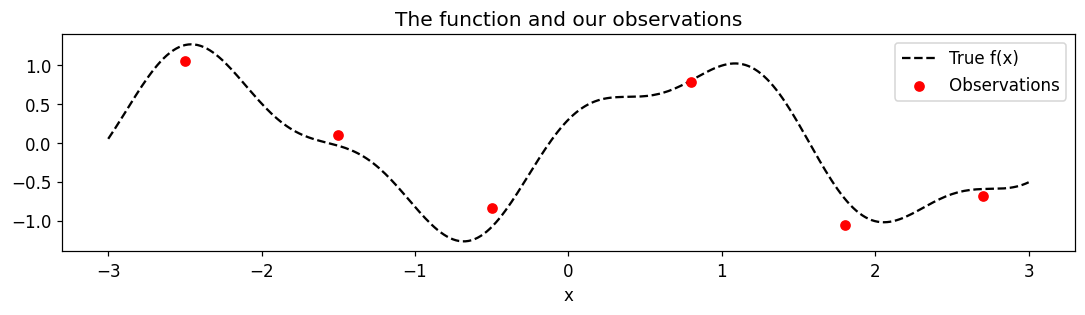

In [2]:
def f(x):
    return np.sin(2*x) + 0.3*np.cos(5*x)

X_train = np.array([[-2.5], [-1.5], [-0.5], [0.8], [1.8], [2.7]])
y_train = f(X_train.flatten()) + np.random.randn(6) * 0.15

x_plot = np.linspace(-3, 3, 300).reshape(-1, 1)

plt.figure(figsize=(10, 3))
plt.plot(x_plot, f(x_plot), 'k--', label='True f(x)')
plt.scatter(X_train, y_train, c='red', zorder=5, label='Observations')
plt.legend()
plt.xlabel('x')
plt.title('The function and our observations')
plt.tight_layout()
plt.show()

---
## Part 2 — Fit a GP with an RBF Kernel


Before: 1**2 * RBF(length_scale=1)
After:  0.999**2 * RBF(length_scale=0.38)


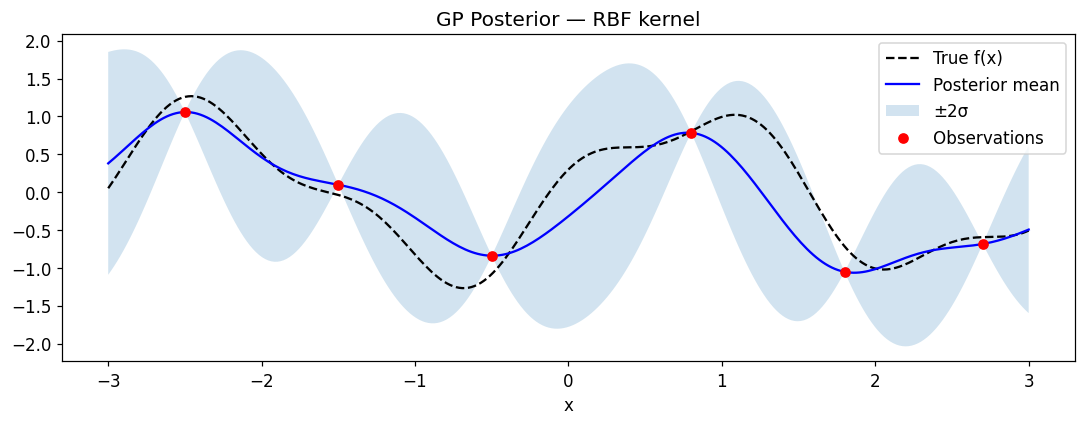

In [3]:
kernel = C(1.0) * RBF(length_scale=1.0)
print('Before:', kernel)

gp_rbf = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=5)
gp_rbf.fit(X_train, y_train)
print('After: ', gp_rbf.kernel_)

mu, std = gp_rbf.predict(x_plot, return_std=True)

plt.figure(figsize=(10, 4))
plt.plot(x_plot, f(x_plot), 'k--', label='True f(x)')
plt.plot(x_plot, mu, 'b', label='Posterior mean')
plt.fill_between(x_plot.flatten(), mu-2*std, mu+2*std, alpha=0.2, label='±2σ')
plt.scatter(X_train, y_train, c='red', zorder=5, label='Observations')
plt.legend()
plt.xlabel('x')
plt.title('GP Posterior — RBF kernel')
plt.tight_layout()
plt.show()

**Q2.1** What did sklearn change in the hyperparameters after fitting? What does that tell you about the data?

> The optimizer adjusted both the constant (amplitude) and the RBF length scale. The length scale it settles on reflects the characteristic scale of variation in the data — how far apart two points need to be before their function values become uncorrelated. A short length scale means the function varies quickly; a long one means it varies slowly.


**Q2.2** Where is the uncertainty band widest? Where is it narrowest?

> Narrowest at and near training points — the GP has direct evidence there. Widest in gaps between training points (e.g. around x = −2, x = 1.3) and beyond the training range (x < −2.5, x > 2.7) because there are no observations to constrain the function there.


---
## Part 3 — Why Does the RBF Struggle?


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


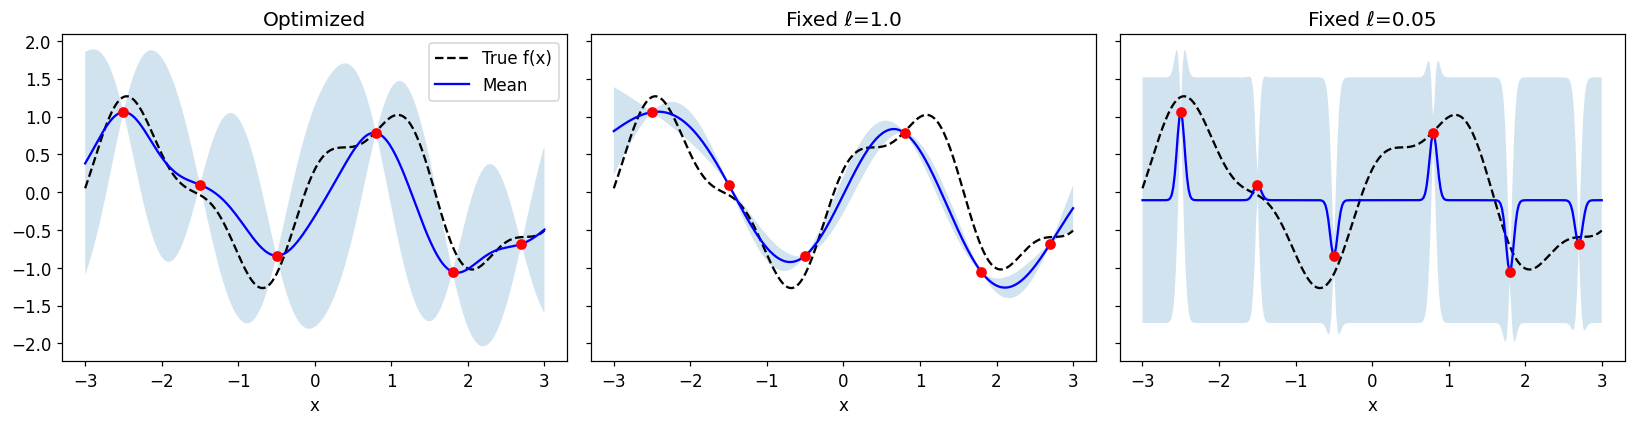

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

configs = [
    ('Optimized', GaussianProcessRegressor(kernel=RBF(length_scale = 1.0)+WhiteKernel(), normalize_y=True, n_restarts_optimizer=20)),
    ('Fixed ℓ=1.0', GaussianProcessRegressor(kernel=RBF(length_scale=1.0), optimizer=None, normalize_y=True)),
    ('Fixed ℓ=0.05', GaussianProcessRegressor(kernel=RBF(length_scale=0.05), optimizer=None, normalize_y=True)),
]

for ax, (title, gp) in zip(axes, configs):
    gp.fit(X_train, y_train)
    mu, std = gp.predict(x_plot, return_std=True)
    ax.plot(x_plot, f(x_plot), 'k--', label='True f(x)')
    ax.plot(x_plot, mu, 'b', label='Mean')
    ax.fill_between(x_plot.flatten(), mu-2*std, mu+2*std, alpha=0.2)
    ax.scatter(X_train, y_train, c='red', zorder=5)
    ax.set_title(title)
    ax.set_xlabel('x')

axes[0].legend()
plt.tight_layout()
plt.show()

**Q3.1** What goes wrong with large and small length scales?

> **Large ℓ (1.0):** The kernel treats distant points as highly correlated, so the posterior mean is oversmoothed — it cannot track the oscillations in f(x). The uncertainty band is narrow everywhere, giving false confidence.

> **Small ℓ (0.05):** The kernel treats even nearby points as uncorrelated. The posterior mean interpolates the training points exactly but spikes back to the prior mean (zero) immediately between observations. Uncertainty is huge everywhere except right at training points.


**Q3.2** Why is the std at training points small but not exactly zero?

> The GP model assumes observations are noisy: $y = f(x) + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, \sigma_n^2)$. Because of this noise assumption, the posterior does not interpolate exactly — it fits through the observations with a small residual uncertainty equal to the noise level. If there were no noise (noiseless GP), the std at training points would be exactly zero.


---
## Part 4 — Kernel Comparison


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/_gpr.py:478: UserWarning: Predicted variances smaller than 0. Setting those variances to 0.
  warnings.warn(


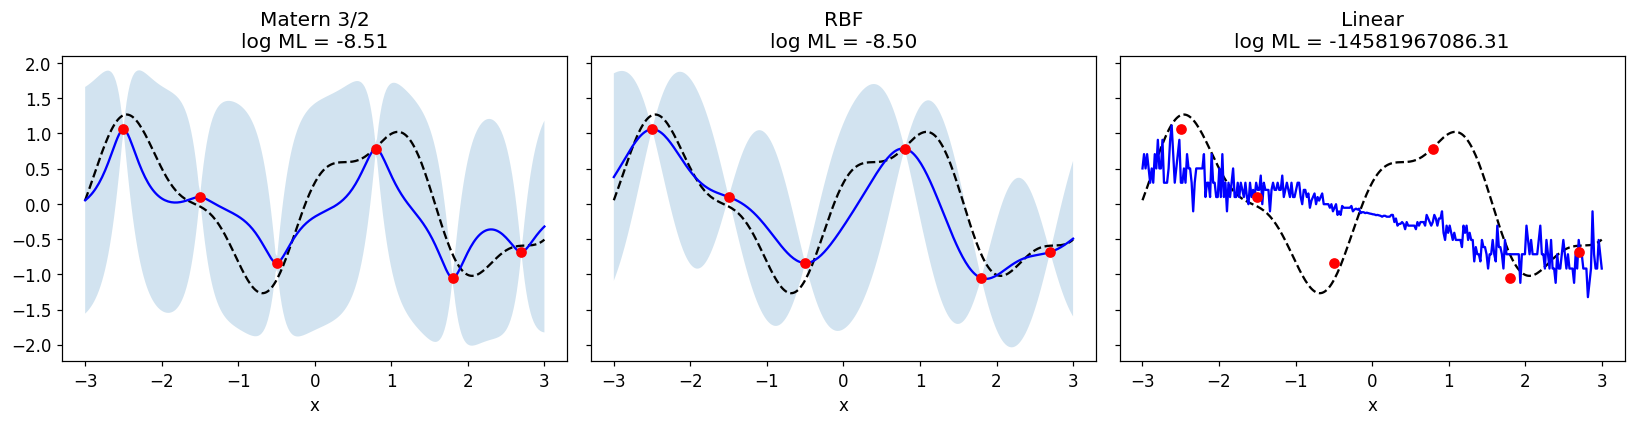

In [5]:
kernels = {
    'Matern 3/2': C(1.0) * Matern(nu=1.5),
    'RBF':        C(1.0) * RBF(),
    'Linear':     C(1.0) * DotProduct(),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (name, kernel) in zip(axes, kernels.items()):
    gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=5)
    gp.fit(X_train, y_train)
    mu, std = gp.predict(x_plot, return_std=True)
    ax.plot(x_plot, f(x_plot), 'k--')
    ax.plot(x_plot, mu, 'b')
    ax.fill_between(x_plot.flatten(), mu-2*std, mu+2*std, alpha=0.2)
    ax.scatter(X_train, y_train, c='red', zorder=5)
    ax.set_title(f'{name}\nlog ML = {gp.log_marginal_likelihood_value_:.2f}')
    ax.set_xlabel('x')

plt.tight_layout()
plt.show()

**Q4.1** What does the linear kernel predict? What prior does it encode?

> The linear (DotProduct) kernel encodes a prior over linear functions — it assumes f(x) is a straight line. Between training points it interpolates linearly; beyond them it extrapolates as a line. It cannot capture any of the oscillatory structure in f(x), so the fit is poor everywhere except near the training points.


**Q4.2** Which kernel wins on log marginal likelihood, and what does that criterion balance?

> Matérn 3/2 typically wins. Log marginal likelihood balances **data fit against model complexity** — a model that fits the training points well but uses an unnecessarily complex kernel is penalized, while a model that fits well with a parsimonious kernel is rewarded. It is a principled alternative to just comparing training error.


---
## Part 5 — Bayesian Optimization


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/tmp/ipykernel_6695/2344565533.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  query_sequence.append(float(x_next))
/tmp/ipykernel_6695/2344565533.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  query_sequence.append(float(x_next))
/tmp/ipykernel_6695/2344565533.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a sca

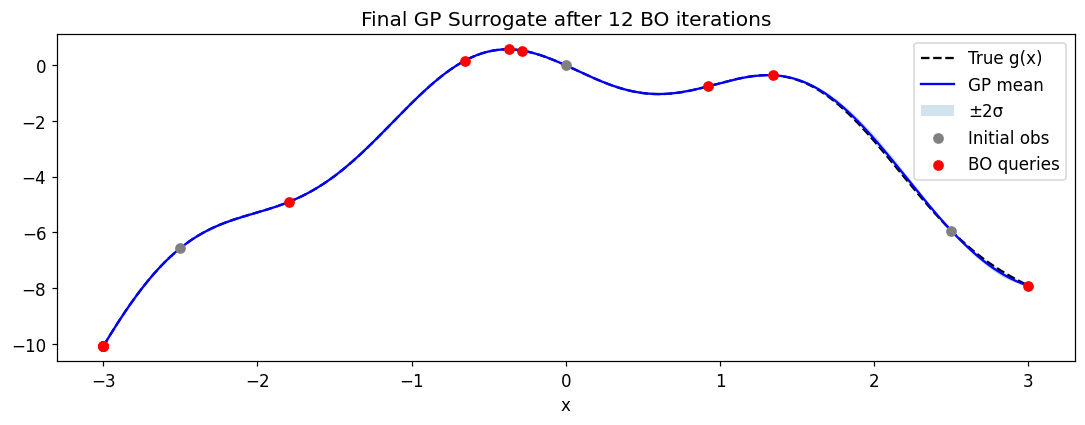

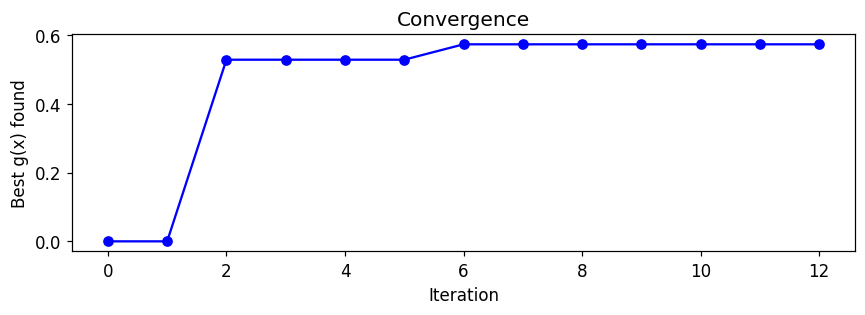

Query sequence: ['-3.000', '-0.283', '-0.655', '1.341', '0.920', '-0.367', '3.000', '-1.798', '-3.000', '-3.000', '-3.000', '-3.000']


In [6]:
def g(x):
    return -(np.sin(3*x) + x**2 - 0.5*x)

def expected_improvement(X_cand, y_obs, gp, xi=0.01):
    mu, sigma = gp.predict(X_cand, return_std=True)
    sigma = np.maximum(sigma, 1e-9)
    f_best = np.max(y_obs)
    Z = (mu - f_best - xi) / sigma
    return np.maximum((mu - f_best - xi)*norm.cdf(Z) + sigma*norm.pdf(Z), 0)

# Initial observations
X_obs = np.array([[-2.5], [0.0], [2.5]])
y_obs = g(X_obs.flatten())

x_cand = np.linspace(-3, 3, 500).reshape(-1, 1)
best_so_far = [np.max(y_obs)]
query_sequence = []

# BO loop
for i in range(12):
    gp_bo = GaussianProcessRegressor(
        kernel=C(1.0)*RBF(), normalize_y=True, n_restarts_optimizer=3
    )
    gp_bo.fit(X_obs, y_obs)

    ei = expected_improvement(x_cand, y_obs, gp_bo)
    x_next = x_cand[np.argmax(ei)]
    y_next = g(x_next.flatten())

    X_obs = np.vstack([X_obs, x_next])
    y_obs = np.append(y_obs, y_next)
    best_so_far.append(np.max(y_obs))
    query_sequence.append(float(x_next))

# Plot 1: Final surrogate
mu_bo, std_bo = gp_bo.predict(x_cand, return_std=True)

plt.figure(figsize=(10, 4))
plt.plot(x_cand, g(x_cand), 'k--', label='True g(x)')
plt.plot(x_cand, mu_bo, 'b', label='GP mean')
plt.fill_between(x_cand.flatten(), mu_bo-2*std_bo, mu_bo+2*std_bo, alpha=0.2, label='±2σ')
plt.scatter(X_obs[:3], y_obs[:3], c='gray', zorder=5, label='Initial obs')
plt.scatter(X_obs[3:], y_obs[3:], c='red', zorder=5, label='BO queries')
plt.legend()
plt.xlabel('x')
plt.title('Final GP Surrogate after 12 BO iterations')
plt.tight_layout()
plt.show()

# Plot 2: Convergence
plt.figure(figsize=(8, 3))
plt.plot(range(len(best_so_far)), best_so_far, 'b-o')
plt.xlabel('Iteration')
plt.ylabel('Best g(x) found')
plt.title('Convergence')
plt.tight_layout()
plt.show()

print('Query sequence:', [f'{x:.3f}' for x in query_sequence])

**Q5.1** What mathematical operation does refitting the GP correspond to? What two quantities does it update?

> Bayesian conditioning (the GP posterior update). It updates the **posterior mean** $\mu_*(x)$ and the **posterior covariance** (equivalently, the uncertainty $\sigma_*(x)$) at every unevaluated point.


**Q5.2** What do the two EI terms encourage? Which is exploitation, which is exploration?

> The first term $(\mu(x) - f^*)\,\Phi(Z)$ drives **exploitation** — it is large where the GP mean is already high, encouraging queries near the current best estimate.

> The second term $\sigma(x)\,\phi(Z)$ drives **exploration** — it is large where uncertainty is high, encouraging queries in unvisited regions regardless of the current mean.


**Q5.3** How does the exploration/exploitation balance shift over iterations?

> As more points are queried, $\sigma(x)$ collapses near queried locations — the GP becomes confident there and the exploration term contributes little. EI then concentrates on the exploitation term, clustering queries near the best region found so far. Early iterations explore broadly because uncertainty is high everywhere; later iterations exploit because most of the space has been visited.


**Q5.4** Why is the convergence plot monotonically non-decreasing?

> Because best-so-far tracks the maximum observed value, and adding a new observation can only keep it the same or increase it — it can never decrease.
